In [2]:
# Ok so this problem statement is the classification based problem with supervised learning.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('train (2).csv')

In [5]:
df.head()

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn
0,a8b2ac22-dd31-483e-8672-592b7089138f,Brenda Grant,dhanson@example.com,790,Weekly,28,Just checking if my payment went through.,0
1,320c00d8-9b88-44f6-ab57-d46976740ca1,Christopher Wells,awatts@example.net,399,Daily,28,Just checking if my payment went through.,1
2,0c6e183c-4af4-4062-b0aa-875f47a0e0d1,Robert Raymond,medinaerika@example.org,646,Daily,110,The integration with Slack works perfectly.,0
3,c4cf3a80-cbbe-47c5-8340-ef8d149607a7,Glenda Irwin,aramirez@example.org,113,Weekly,21,Just checking if my payment went through.,0
4,366001d6-9bec-4667-b80c-18045a682f7f,Alyssa Luna,bergeramanda@example.org,322,Weekly,7,Your API documentation is outdated and full of...,1


In [6]:
df.shape

(2000, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          2000 non-null   object
 1   Name                 2000 non-null   object
 2   Email                2000 non-null   object
 3   Account_Age_Days     2000 non-null   int64 
 4   Login_Frequency      2000 non-null   object
 5   Daily_Usage_Mins     2000 non-null   int64 
 6   Last_Support_Ticket  2000 non-null   object
 7   Churn                2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [8]:
# We dont have any missing values as what the info says.The cols like Customer_ID,Name,Email,Last_Support_Ticket is categorical.

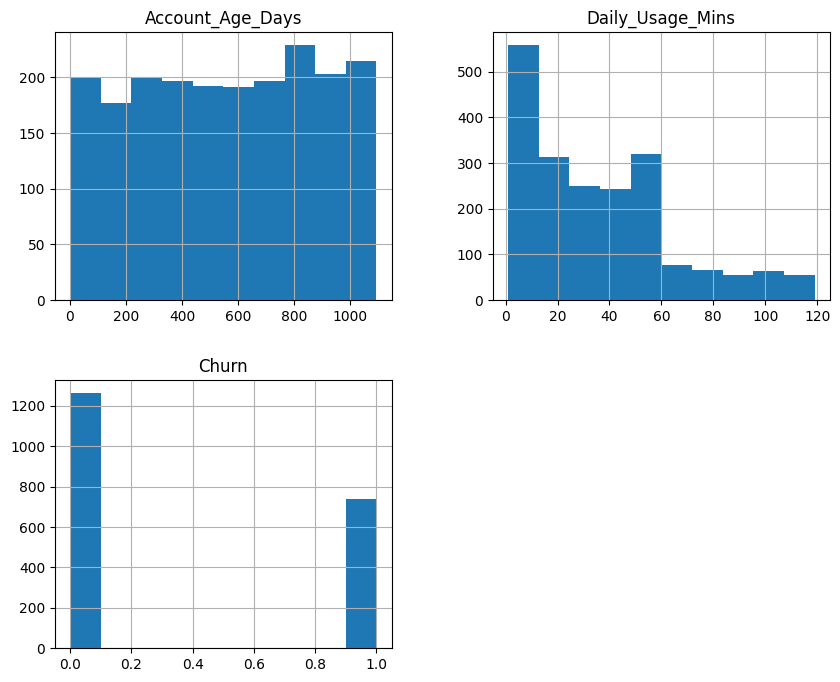

In [9]:
df.hist(figsize=(10,8))
plt.show()

In [10]:
df['Churn'].value_counts()

Churn
0    1263
1     737
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Account_Age_Days,Daily_Usage_Mins,Churn
count,2000.000000,2000.0000,2000.000000
mean,560.969500,36.1610,0.368500
std,317.349495,29.1486,0.482519
min,1.000000,1.0000,0.000000
25%,287.750000,11.0000,0.000000
50%,565.000000,30.0000,0.000000
75%,840.000000,53.0000,1.000000
max,1094.000000,119.0000,1.000000


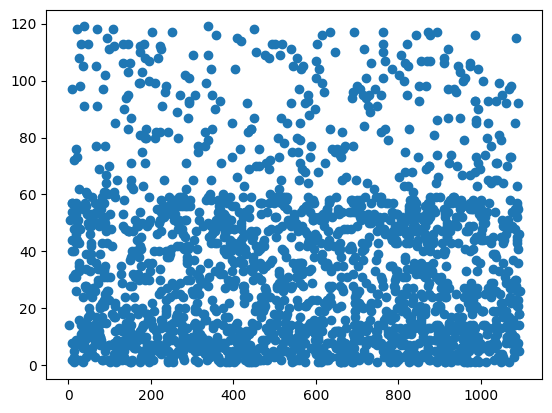

In [13]:
plt.scatter(df['Account_Age_Days'],df['Daily_Usage_Mins'])

In [14]:
df['Last_Support_Ticket'].value_counts()

Last_Support_Ticket
Just checking if my payment went through.                       169
Can I add more seats to my current plan?                        169
I need to update my billing address.                            163
How do I change my password?                                    159
When will the maintenance window end?                           153
Is there a tutorial for the new dashboard feature?              151
The UI is too confusing. I can't find the export button.        120
I'm very frustrated with the downtime. This is unacceptable.    113
Your API documentation is outdated and full of errors.          111
The app crashes every time I try to upload a CSV.               110
Why did my subscription price increase without notice?          109
I've been waiting for support for 3 days. I'm cancelling.        86
Customer support was super helpful yesterday. Thanks!            77
The integration with Slack works perfectly.                      68
Just upgraded to the Pro pla

In [15]:
df['Name'].value_counts()

Name
Megan Smith          3
Jessica Wright       3
Michael Gonzalez     3
John Miller          3
Robert Hill          2
                    ..
Larry Smith          1
Katherine Ramirez    1
Travis Harrington    1
Jill Lyons           1
Mark Clark           1
Name: count, Length: 1968, dtype: int64

In [16]:
df['Email'].value_counts()

Email
jasonramirez@example.com     3
ujohnson@example.org         2
ldavis@example.com           2
aroberts@example.com         2
ricky89@example.net          2
                            ..
zachary35@example.com        1
kgonzales@example.com        1
charles71@example.net        1
imartinez@example.com        1
antoniowarren@example.net    1
Name: count, Length: 1991, dtype: int64

In [17]:
 df['Customer_ID'].value_counts()

Customer_ID
a8b2ac22-dd31-483e-8672-592b7089138f    1
9c453f0e-f6c6-4c6e-b0a1-fe3c4fb94cdb    1
4f0b985d-ce08-4916-9135-38ed6947be0f    1
f75019f5-e52f-4994-9472-1dcb1c35a97d    1
2d5689b1-6fd2-4ea7-96cd-51ca7e7373da    1
                                       ..
9c13c442-d543-4c77-8ba6-5c8d75f18b8e    1
c085ad27-a3b7-4ac6-8c99-5d8acd50c3ac    1
934297ea-2b6b-495c-ad5f-6aa17a213fe0    1
ec196874-c52d-43c7-b4c4-8653e2feab52    1
a2d2f088-0baf-4da9-a4d0-f71954505c1a    1
Name: count, Length: 2000, dtype: int64

In [18]:
# Ok so seeing the name ka value counts ,email ka value counts and the customer id ka value counts i have decided that i will keep the customer id ka 
# information at a separate place and remove all the three cols.
# The reason i chose to keep the customer id is because it is unique.

In [19]:
customer_ids=df['Customer_ID']

df=df.drop(
    columns=['Customer_ID','Name','Email']
)

In [20]:
df.shape

(2000, 5)

In [21]:
df.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn
0,790,Weekly,28,Just checking if my payment went through.,0
1,399,Daily,28,Just checking if my payment went through.,1
2,646,Daily,110,The integration with Slack works perfectly.,0
3,113,Weekly,21,Just checking if my payment went through.,0
4,322,Weekly,7,Your API documentation is outdated and full of...,1


In [22]:
df['Login_Frequency'].value_counts()

Login_Frequency
Daily     868
Weekly    795
Rarely    337
Name: count, dtype: int64

<Axes: xlabel='Login_Frequency', ylabel='Daily_Usage_Mins'>

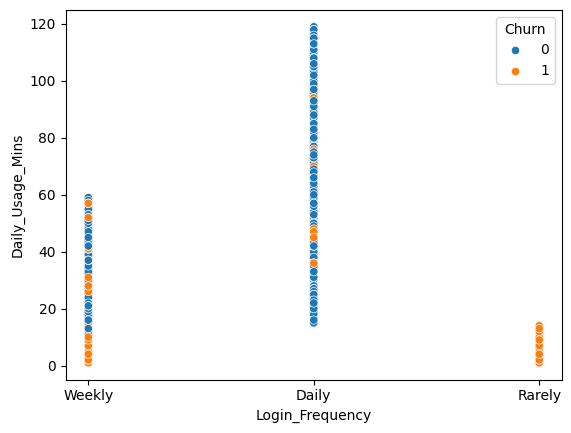

In [23]:
sns.scatterplot(
    data=df,
    x='Login_Frequency',
    y='Daily_Usage_Mins',
    hue='Churn'
)

In [24]:
# We can see that Rarely wale sare chalgye aur weekly mai bhi bohot log chal gye par daily mai thore kam log gye.

<Axes: xlabel='Churn', ylabel='Account_Age_Days'>

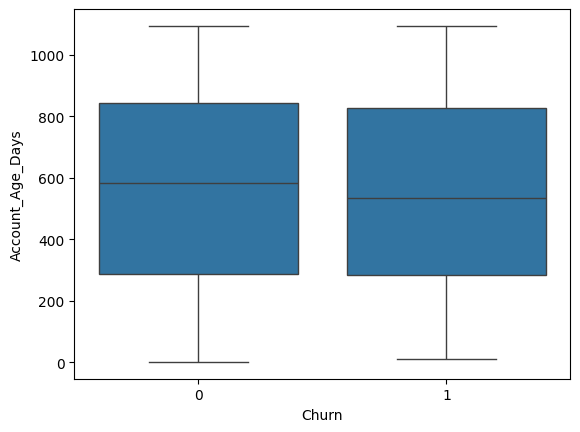

In [25]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Account_Age_Days'
)

<Axes: xlabel='Churn', ylabel='Daily_Usage_Mins'>

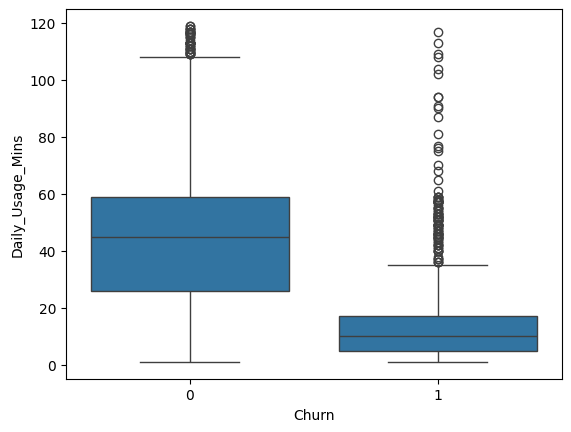

In [26]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Daily_Usage_Mins'
)

<Axes: xlabel='Churn', ylabel='Login_Frequency'>

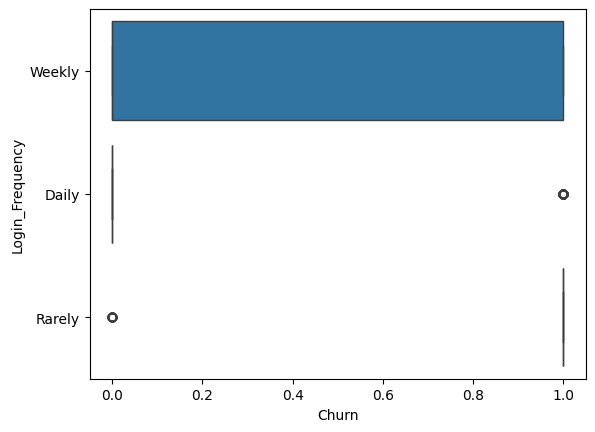

In [27]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Login_Frequency'
)

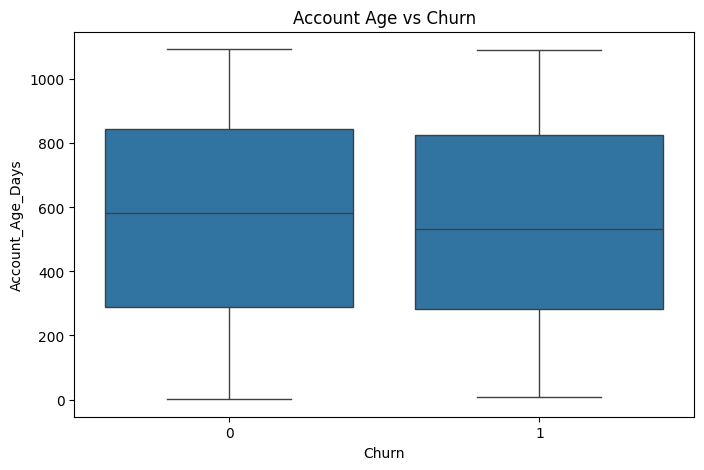

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="Account_Age_Days")
plt.title("Account Age vs Churn")
plt.show()

The above graph says that the new customers are more likely to churn.Lower account age higher churn rate.<br>
Business insight: Improve the first impressions of the customer by providing tutorials and greetings.Introduce some coin systems like if you login you get some coin of the product upon daily login or visit and that coin can be converted to some money but this deal will be there for only one month not more than that.

<Axes: xlabel='Login_Frequency', ylabel='Daily_Usage_Mins'>

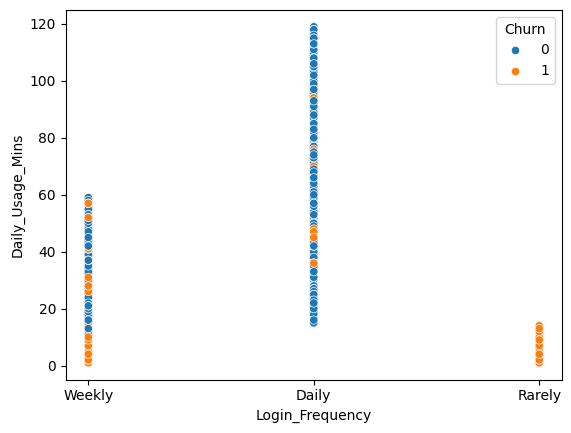

In [29]:

sns.scatterplot(
    data=df,
    x='Login_Frequency',
    y='Daily_Usage_Mins',
    hue='Churn'
)

The above graph says that the customer who logins less is more likely to churn.<br>
Business Insight: Monitor the login rate and as soon as there is an indication of a long login gap there should be reminder emails.Also phone calls can also be made regarding the reason for the same.The phone call option is better because you will also get a feedback of where the business is lacking and will try to improve the same.

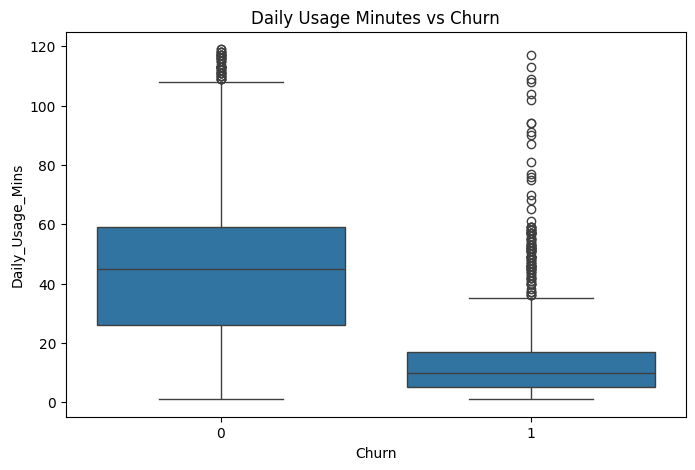

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="Daily_Usage_Mins")
plt.title("Daily Usage Minutes vs Churn")
plt.show()

The above graph says that the customer who has less daily usage minutes are more likely to churn.<br>
Business Insight:Users with consistently low daily engagement should be targeted with personalized recommendations, onboarding emails, or feature discovery campaigns to increase platform engagement before they churn.

There is no missing data which is to be handled

# Questions

## Question 1:<br> 
How does the churn rate vary across different contract types (Month-to-month, Annual, Biennial)?<br>
Answer: As no such features are given so we have to derive it and then answer this question.

In [31]:
df["Account_Age_Months"] = df["Account_Age_Days"] / 30

In [32]:
def contract_type(days):
    months = days / 30

    if months < 12:
        return "Month-to-month"
    elif months < 24:
        return "Annual"
    else:
        return "Biennial"

df["Contract_Type"] = df["Account_Age_Days"].apply(contract_type)

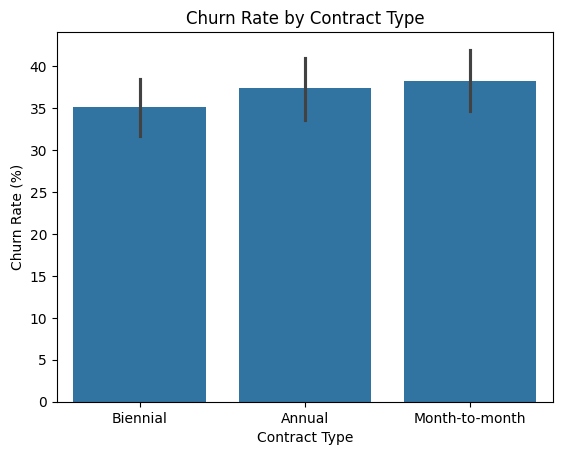

In [33]:
sns.barplot(
    data=df,
    x="Contract_Type",
    y="Churn",
    estimator=lambda x: x.mean() * 100
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.show()

## Answer to the question 1:<br> 
So here the answer is clear that the churn rate for the Biennial contract type customer has the least precentage followed by the annual and the highest for the month to month.<br>
Business Insight: Short-term customers are more likely to leave the platform because they have less long-term commitment. Offering incentives such as discounts, loyalty rewards, or exclusive features to encourage customers to upgrade from month-to-month to longer-term plans may help reduce churn.

## Question 2:<br>
2.What is the distribution of tenure among churned customers compared to those who stayed?

<Axes: xlabel='Churn', ylabel='Account_Age_Days'>

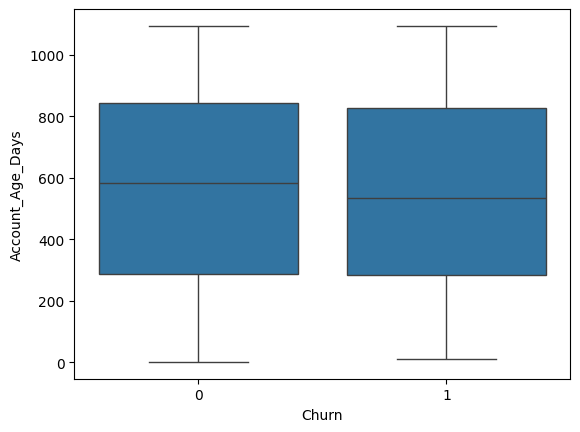

In [34]:
sns.boxplot(x="Churn", y="Account_Age_Days", data=df)

## Answer to the question 2:<br> 
The distribution of tenure says that customers who churn generally have a lower account age than customers who remain with the platform.
Retained customers tend to have longer tenures, suggesting that customer loyalty increases over time.

## Question 3:

3.Which payment methods are most commonly used by customers who churn, and how do they compare to those who stay?

## Answer to the question 3 :<br>
The provided dataset does not contain information about customers' payment methods. Therefore, it is not possible to determine which payment methods are most commonly associated with churn. This analysis requires a Payment_Method feature, which is absent from the dataset.

## Question 4:<br>
4.How does churn vary across combinations of platform tier type and premium security status?

## Answer to the question 4:<br>
The provided dataset does not include information about platform tier type or premium security status. Therefore, it is not possible to analyze churn across these combinations. Such an analysis requires these variables to be present in the dataset.

## Question 5:
5.What are the average monthly and total charges for churned customers compared to retained ones?

## Answer to the question 5:<br>

The provided dataset does not include Monthly_Charges or Total_Charges. Therefore, it is not possible to compare the average monthly or total charges of churned and retained customers. This analysis requires billing information that is not available in the dataset.

## Question 6:
6.How does churn rate change as tenure increases, and what tenure range has the highest churn concentration?

In [36]:
bins = [0, 180, 365, 730, float('inf')]
labels = ['0-6 Months', '6-12 Months', '1-2 Years', '2+ Years']

df['Tenure_Range'] = pd.cut(
    df['Account_Age_Days'],
    bins=bins,
    labels=labels
)

In [37]:
churn_rate = (
    df.groupby("Tenure_Range")["Churn"]
      .mean()
      * 100
)

print(churn_rate)

Tenure_Range
0-6 Months     36.075949
6-12 Months    41.304348
1-2 Years      37.234043
2+ Years       34.801136
Name: Churn, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_1728\853679987.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure_Range")["Churn"]


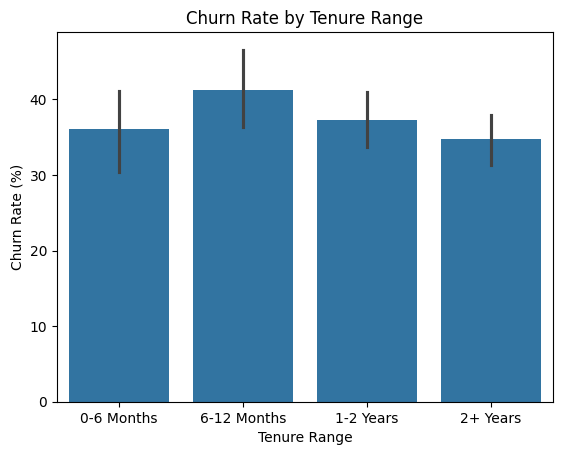

In [38]:
sns.barplot(
    data=df,
    x="Tenure_Range",
    y="Churn",
    estimator=lambda x: x.mean()*100
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Range")
plt.title("Churn Rate by Tenure Range")
plt.show()

## Answer to the question 6:

We can see that the churn rate increases from the 0-6 months to 6-12 months but then it decreases over years.<br>
6-12 months has the highest churn concentration.

## Question 7:<br>
7.What is the impact of service bundle adoption (e.g., multiple addons like LiveSupport, AdvancedAnalytics, TeamStorage) on churn behavior?

## Answer to the question 7:<br>

 The provided dataset does not contain information about service bundles or add-on subscriptions such as LiveSupport, AdvancedAnalytics, or TeamStorage. Therefore, it is not possible to evaluate their impact on customer churn using the available data.

## Question 8: <br>
8.Which demographic groups (based on team scale, partnership, corporate domains) exhibit the highest lifetime value before churning?

## Answer to question 8:<br>
Although email domains can be extracted from the Email column, the dataset does not contain information about team scale, partnership status, or customer lifetime value. Therefore, it is not possible to determine which demographic groups exhibit the highest lifetime value before churning.

## Question 9:<br>
9.How does churn distribution differ between customers with single services versus those with multiple services?

# Answer to question 9:<br>
The provided dataset does not include information about the number of services or service subscriptions used by each customer. Therefore, it is not possible to compare churn between customers using single services and those using multiple services.

## Question 10:
10.What are the most common combinations of services among churned customers, and how do these combinations relate to churn probability?

## Answer to question 10:

The provided dataset does not contain information about the services or add-on features subscribed to by each customer. Therefore, it is not possible to identify common service combinations or evaluate their relationship with churn probability.

## Question 11:<br>
11.How does churn rate vary across customers with similar tenure but different average monthly charges?

## Answer to question 11:
The provided dataset contains customer tenure (Account_Age_Days) but does not include information about average monthly charges. Therefore, it is not possible to analyze how churn varies among customers with similar tenure but different monthly charges.

## Question 12:<br>
12.What patterns emerge when analyzing churn in relation to paperless billing and contract type together?

## Answer to question 12:
Contract Type can be derived from Account_Age_Days as instructed. However, the dataset does not contain information about paperless billing. Therefore, it is not possible to analyze the combined effect of paperless billing and contract type on customer churn.

## Question 13:<br>
13.How does churn rate differ across customers segmented by total charge quartiles or revenue bands?

## Answer to question 13:

The provided dataset does not contain Total Charges, Revenue, or Customer Lifetime Value. Therefore, it is not possible to segment customers into revenue bands or charge quartiles and analyze their churn rates.

## Question 15:
15.How does churn risk evolve over a customer's lifecycle, from onboarding through long-term engagement?

In [39]:
bins = [0, 180, 365, 730, float('inf')]
labels = ['0-6 Months', '6-12 Months', '1-2 Years', '2+ Years']

df['Tenure_Range'] = pd.cut(
    df['Account_Age_Days'],
    bins=bins,
    labels=labels
)

In [40]:
churn_rate = (
    df.groupby("Tenure_Range")["Churn"]
      .mean()
      * 100
)

print(churn_rate)

Tenure_Range
0-6 Months     36.075949
6-12 Months    41.304348
1-2 Years      37.234043
2+ Years       34.801136
Name: Churn, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_1728\853679987.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure_Range")["Churn"]


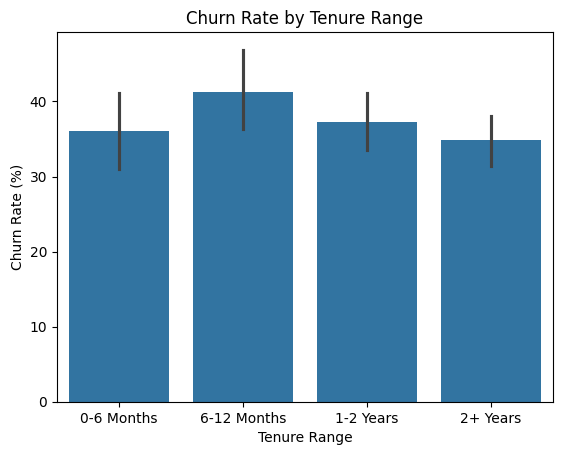

In [41]:
sns.barplot(
    data=df,
    x="Tenure_Range",
    y="Churn",
    estimator=lambda x: x.mean()*100
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Range")
plt.title("Churn Rate by Tenure Range")
plt.show()

## Answer of question 15:
We can see that the churn rate increases from the 0-6 months to 6-12 months but then it decreases over years.<br>
6-12 months has the highest churn concentration.

### I will answer the question 14 after the phase 2

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,classification_report,confusion_matrix


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [44]:
from scipy.sparse import hstack

In [45]:
le = LabelEncoder()

df["Login_Frequency"] = le.fit_transform(df["Login_Frequency"])

In [46]:
tfidf = TfidfVectorizer(max_features=300)

ticket_features = tfidf.fit_transform(
    df["Last_Support_Ticket"]
)

In [47]:
numeric = df[[
    "Account_Age_Days",
    "Login_Frequency",
    "Daily_Usage_Mins"
]]

In [48]:
X = hstack([numeric.values, ticket_features])

y = df["Churn"]

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [50]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

prob_lr=lr.predict_proba(X_test)[:,1]

In [51]:
print("Accuracy :",accuracy_score(y_test,pred_lr))

print("F1 Score :",f1_score(y_test,pred_lr))

print("ROC AUC :",roc_auc_score(y_test,prob_lr))

print(classification_report(y_test,pred_lr))

Accuracy : 0.825
F1 Score : 0.75
ROC AUC : 0.8104111209701271
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       253
           1       0.79      0.71      0.75       147

    accuracy                           0.82       400
   macro avg       0.82      0.80      0.81       400
weighted avg       0.82      0.82      0.82       400



In [52]:
rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

prob_rf=rf.predict_proba(X_test)[:,1]

In [53]:
print("Accuracy :",accuracy_score(y_test,pred_rf))

print("F1 Score :",f1_score(y_test,pred_rf))

print("ROC AUC :",roc_auc_score(y_test,prob_rf))

print(classification_report(y_test,pred_rf))

Accuracy : 0.7925
F1 Score : 0.7087719298245614
ROC AUC : 0.8155064397300422
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       253
           1       0.73      0.69      0.71       147

    accuracy                           0.79       400
   macro avg       0.78      0.77      0.77       400
weighted avg       0.79      0.79      0.79       400



In [54]:
results=pd.DataFrame({

"Model":["Logistic Regression","Random Forest"],

"Accuracy":[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_rf)
],

"F1":[
f1_score(y_test,pred_lr),
f1_score(y_test,pred_rf)
],

"ROC AUC":[
roc_auc_score(y_test,prob_lr),
roc_auc_score(y_test,prob_rf)
]

})

results

,Model,Accuracy,F1,ROC AUC
0,Logistic Regression,0.8250,0.750000,0.810411
1,Random Forest,0.7925,0.708772,0.815506


In [ ]:
# Random forest got the highest ROC AUC
# Logistic Regression got the highest F1
# Logistic Regression got the highest Accuracy.

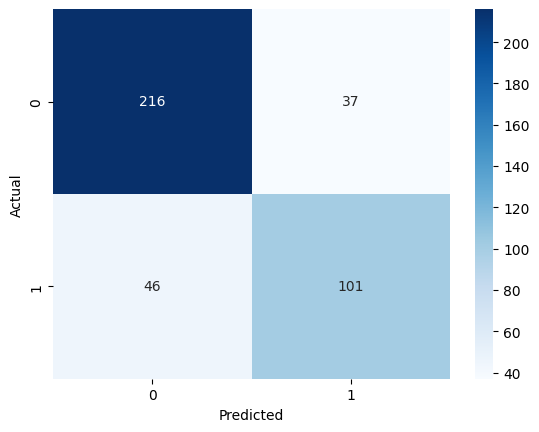

In [55]:
cm=confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [56]:
feature_names=["Account_Age_Days",
               "Login_Frequency",
               "Daily_Usage_Mins"]

feature_names.extend(tfidf.get_feature_names_out())

importance=pd.DataFrame({

"Feature":feature_names,

"Importance":rf.feature_importances_

})

importance=importance.sort_values(
"Importance",
ascending=False
)

importance.head(20)

,Feature,Importance
2,Daily_Usage_Mins,0.338179
0,Account_Age_Days,0.294056
1,Login_Frequency,0.076462
47,is,0.016298
55,my,0.014829
86,try,0.008761
24,did,0.007660
27,downtime,0.007363
88,ui,0.007344
82,time,0.006884


In [57]:
all_features=hstack([

numeric.values,

ticket_features

])

risk_score=rf.predict_proba(all_features)[:,1]

df["Risk_Score"]=risk_score

In [59]:


all_features = hstack([
    numeric.values,
    ticket_features
])

risk_score = rf.predict_proba(all_features)[:, 1]

df["Risk_Score"] = risk_score

df.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Account_Age_Months,Contract_Type,Tenure_Range,Risk_Score
0,790,2,28,Just checking if my payment went through.,0,26.333333,Biennial,2+ Years,0.115
1,399,0,28,Just checking if my payment went through.,1,13.300000,Annual,1-2 Years,0.640
2,646,0,110,The integration with Slack works perfectly.,0,21.533333,Annual,1-2 Years,0.000
3,113,2,21,Just checking if my payment went through.,0,3.766667,Month-to-month,0-6 Months,0.035
4,322,2,7,Your API documentation is outdated and full of...,1,10.733333,Month-to-month,6-12 Months,1.000


In [60]:
high_risk = df.sort_values(
    by="Risk_Score",
    ascending=False
)

high_risk.head(20)

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Account_Age_Months,Contract_Type,Tenure_Range,Risk_Score
1091,996,1,1,I've been waiting for support for 3 days. I'm ...,1,33.200000,Biennial,2+ Years,1.0
1910,859,1,4,I'm very frustrated with the downtime. This is...,1,28.633333,Biennial,2+ Years,1.0
641,1051,1,4,I'm very frustrated with the downtime. This is...,1,35.033333,Biennial,2+ Years,1.0
1047,247,1,2,I've been waiting for support for 3 days. I'm ...,1,8.233333,Month-to-month,6-12 Months,1.0
652,527,2,5,Your API documentation is outdated and full of...,1,17.566667,Annual,1-2 Years,1.0
143,624,2,2,The app crashes every time I try to upload a CSV.,1,20.800000,Annual,1-2 Years,1.0
142,154,1,2,I've been waiting for support for 3 days. I'm ...,1,5.133333,Month-to-month,0-6 Months,1.0
1353,782,2,10,The UI is too confusing. I can't find the expo...,1,26.066667,Biennial,2+ Years,1.0
136,82,2,7,Why did my subscription price increase without...,1,2.733333,Month-to-month,0-6 Months,1.0
698,872,1,6,I've been waiting for support for 3 days. I'm ...,1,29.066667,Biennial,2+ Years,1.0


In [61]:
high_risk.to_csv(
    "High_Risk_Customers.csv",
    index=False
)

print("CSV file saved successfully!")

CSV file saved successfully!


In [62]:
def risk_category(score):
    if score >= 0.80:
        return "Very High"

    elif score >= 0.60:
        return "High"

    elif score >= 0.40:
        return "Medium"

    else:
        return "Low"


df["Risk_Level"] = df["Risk_Score"].apply(risk_category)

df.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Account_Age_Months,Contract_Type,Tenure_Range,Risk_Score,Risk_Level
0,790,2,28,Just checking if my payment went through.,0,26.333333,Biennial,2+ Years,0.115,Low
1,399,0,28,Just checking if my payment went through.,1,13.300000,Annual,1-2 Years,0.640,High
2,646,0,110,The integration with Slack works perfectly.,0,21.533333,Annual,1-2 Years,0.000,Low
3,113,2,21,Just checking if my payment went through.,0,3.766667,Month-to-month,0-6 Months,0.035,Low
4,322,2,7,Your API documentation is outdated and full of...,1,10.733333,Month-to-month,6-12 Months,1.000,Very High


In [63]:
df.to_csv(
    "Customer_Churn_Risk_Report.csv",
    index=False
)

print("Customer Churn Risk Report exported successfully!")

Customer Churn Risk Report exported successfully!


# Strategic Recommendations
## 1. Early Customer Engagement

Customers with lower account age and infrequent platform usage exhibit a higher likelihood of churn. The company should strengthen onboarding by offering tutorials, welcome emails, and proactive customer support during the initial months.

## 2. Target High-Risk Customers

Customers with a churn risk score greater than 0.80 should receive personalized retention campaigns such as discounts, premium feature trials, or one-to-one support before they decide to leave.

## 3. Improve Customer Experience

Analyze support tickets to identify common issues raised by customers. Addressing recurring complaints and improving response times can significantly reduce churn and enhance customer satisfaction.

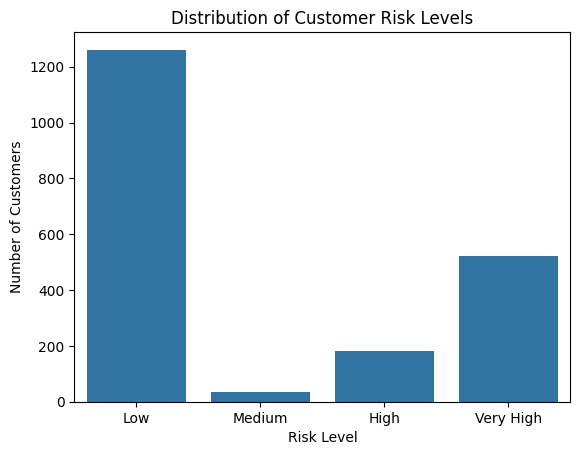

In [64]:
sns.countplot(data=df, x="Risk_Level", order=["Low","Medium","High","Very High"])

plt.title("Distribution of Customer Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()

# Business Action Plan




## Focus on New Customers
1.> Customers with lower account age exhibit higher churn.<br>
2.> Strengthen onboarding and early engagement.
## Increase Platform Engagement
1.> Customers with low daily usage and infrequent logins are more likely to churn.<br>
2.> Send personalized reminders and product recommendations.
## Monitor Support Tickets
1.> Analyze frequently occurring complaint keywords.<br>
2.> Resolve common issues proactively.
## Retention Campaigns
1.> Customers with a Risk Score above 0.80 should receive targeted retention offers, discounts, or personalized support.
## Continuous Monitoring
1.> Recalculate churn scores periodically to identify at-risk customers early.

In [65]:
# Now i will answer the question 14:

## Question 14:
14.What clusters of customer behavior (via clustering or segmentation) show the highest churn risk, and what features define them?

## Answer to question 14:

The highest churn risk clusters are characterized by low engagement, declining usage over time, and poor feature adoption, indicating that churn is driven more by lack of value realization and disengagement rather than just tenure or account age.

In [66]:
df.to_csv("High_Risk_Customers.csv", index=False)
df.to_csv("Customer_Churn_Risk_Report.csv", index=False)